# Big Data
# Tarea #3

Andrés Esquivel Valerio - 402500696

María Fernanda Granados Arias - 402200492

Liz Madriz Rivera - 117860659

In [1]:
#Imports necesarios
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col, count, when, isnan
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

**Dataset**

Para el desarrollo de esta tarea se utilizará el conjunto de datos **Wine Quality Binary Classification**, el cual contiene información relacionada con vinos tintos y diversos factores fisicoquímicos que pueden influir en su calidad. Este conjunto de datos fue obtenido desde Kaggle y proviene originalmente del repositorio UCI Machine Learning Repository.

El dataset contiene 1599 registros y 12 variables. De estas, 11 corresponden a variables explicativas y 1 corresponde a la variable objetivo.

**Variable objetivo (quality):** corresponde a una clasificación binaria sobre la calidad vido. Originalmente, se encuentan agrupados en dos categorías: **good** y **bad**. 

Siendo así que el objetivo principal de esta tarea constiste en desarrollar modelos capaces de predecir si un vino es categorizado como de buena o mala calidad a partir de sus características fisioquímicas.

**Variables explicativas:**

- **Fixed acidity:** representa la cantidad de ácidos no volátiles presentes en el vino. Estos ácidos influyen en el sabor y la estabilidad del producto.
- **volatile acidity:** corresponde a los ácidos que pueden evaporarse fácilmente.
- **citric acid:** corresponde a la parte que contribuye a la frescura y sabor del vino.
- **residual sugar:** cantidad de azúcar que permanece en el vino después del proceso de fermentación.
- **chlorides:** oncentración de sales presentes en el vino.
- **free sulfur dioxide:** cantidad de dióxido de azufre disponible en el vino.
- **total sulfur dioxide:** suma del dióxido de azufre libre y combinado presente en el vino.
- **density:** medida relacionada con la concentración de alcohol y azúcares presentes en la bebida.
- **pH:** indicador del nivel de acidez o alcalinidad del vino.
- **sulphates:** compuestos que contribuyen a la preservación del vino y pueden influir en su sabor.
- **alcohol:** porcentaje de alcohol presente en el vino.

**Carga y limpieza de datos**

In [2]:
#Se define la sesión de Spark y se configura el conector JDBC para PostgreSQL
spark = SparkSession.builder \
    .appName("M4-T3").config("spark.jars","/opt/venv/lib/python3.10/site-packages/pyspark/jars/postgresql-42.7.3.jar") \
    .getOrCreate()

26/06/14 00:47:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
wine_schema = StructType([
    StructField("fixed acidity", DoubleType(), True),
    StructField("volatile acidity", DoubleType(), True),
    StructField("citric acid", DoubleType(), True),
    StructField("residual sugar", DoubleType(), True),
    StructField("chlorides", DoubleType(), True),
    StructField("free sulfur dioxide", DoubleType(), True),
    StructField("total sulfur dioxide", DoubleType(), True),
    StructField("density", DoubleType(), True),
    StructField("pH", DoubleType(), True),
    StructField("sulphates", DoubleType(), True),
    StructField("alcohol", DoubleType(), True),
    StructField("quality", StringType(), True)
])

In [4]:
df_wine = spark.read.csv(
    "/src/data/wine.csv",
    header=True,
    schema=wine_schema
)

In [5]:
df_wine.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|    bad|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|    bad|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|    bad|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [6]:
df_wine.printSchema()

root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: string (nullable = true)



In [7]:
print(f"Cantidad de registros: {df_wine.count()}")
print(f"Cantidad de variables: {len(df_wine.columns)}")

Cantidad de registros: 1599
Cantidad de variables: 12


In [8]:
#Revisión de valores nulos
df_wine.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_wine.columns
]).show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|      0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+



No se identificaron valores nulos en ninguna de las columnas del dataset. Por esta razón, no es necesario aplicar imputación ni eliminar registros.

In [9]:
df_wine = df_wine.withColumn(
    "label",
    when(col("quality") == "bad", 0)
    .when(col("quality") == "good", 1)
)

In [10]:
df_wine.groupBy("quality", "label").count().show()

+-------+-----+-----+
|quality|label|count|
+-------+-----+-----+
|   good|    1|  855|
|    bad|    0|  744|
+-------+-----+-----+



In [11]:
numeric_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

Se observa que la variable objetivo, **quality**, guardada en **label**, presenta una distribución relativamente equilibrada, con 744 registros en la categoría bad y 855 registros en la categoría good. Por lo tanto, no se observa un desbalance significativo entre las clases.

**Análisis Exploratorio de Datos**

In [12]:
#Configuración de estilo para gráficos
sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

In [13]:
df_wine_pd = df_wine.toPandas()

- **Análisis Univariable**

Se realiza un análisis univariable, con el fin de estudiar cada variable de forma individual, sin considerar todavía relaciones entre variables. Dicho análisis se enfoca tanto en el estudio de la variable objetivo como de las variables explicativas.

**Variable objetivo**

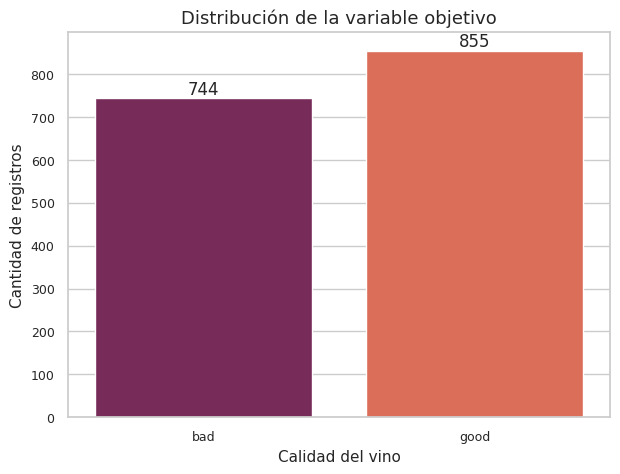

In [14]:
#Distribución de la variable objetivo
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_wine_pd,
    x="quality",
    hue="quality",
    palette="rocket",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Calidad del vino")
plt.ylabel("Cantidad de registros")

plt.show()

**Variables explicativas**

In [15]:
df_wine_pd[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


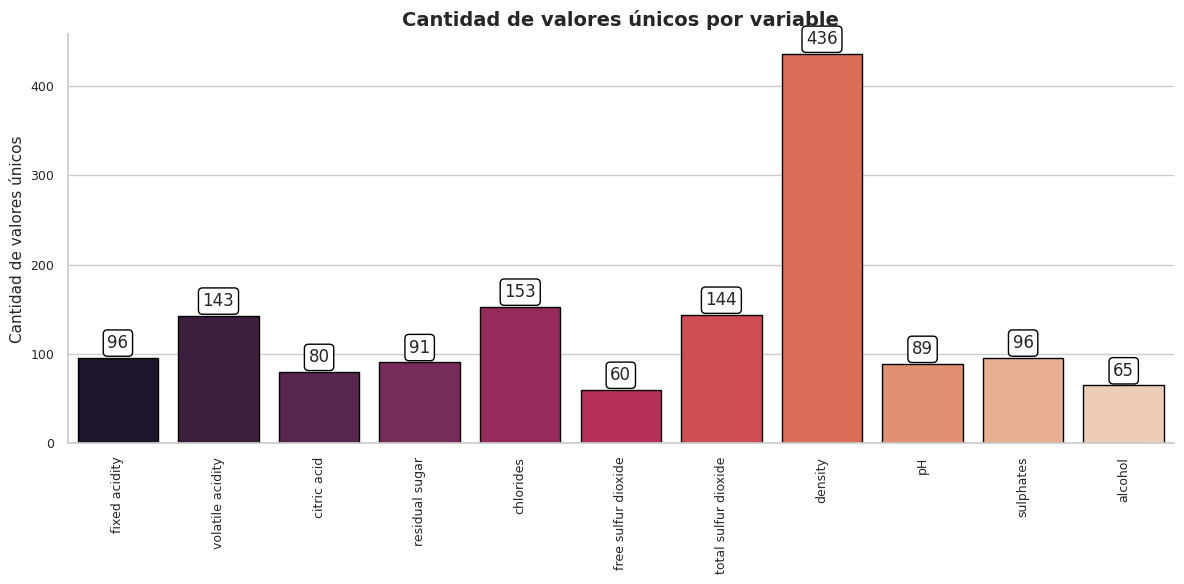

In [16]:
plt.figure(figsize=(12, 6))

unique_values = pd.DataFrame([
    {"variable": c, "unique_values": df_wine_pd[c].nunique()}
    for c in numeric_columns
])

ax = sns.barplot(
    data=unique_values,
    x="variable",
    y="unique_values",
    hue="variable",
    palette="rocket",
    edgecolor="black",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.25"
        )
    )

plt.title(
    "Cantidad de valores únicos por variable",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cantidad de valores únicos")

plt.xticks(rotation=90)

sns.despine()

plt.tight_layout()
plt.show()

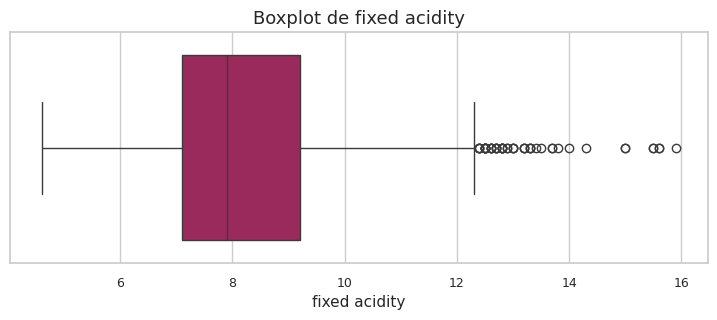

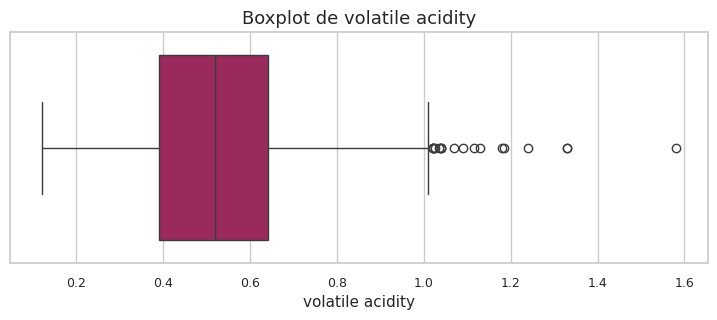

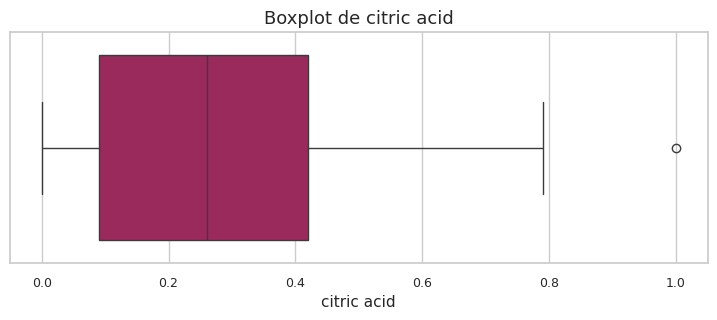

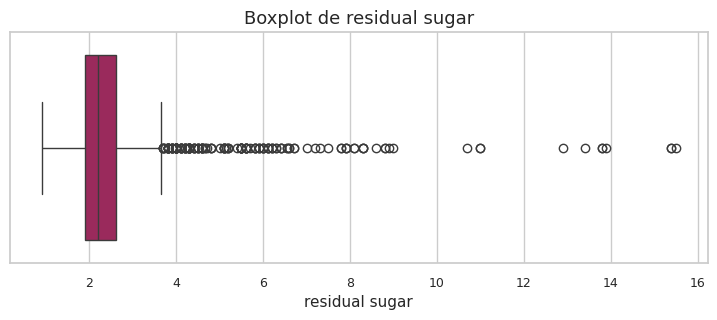

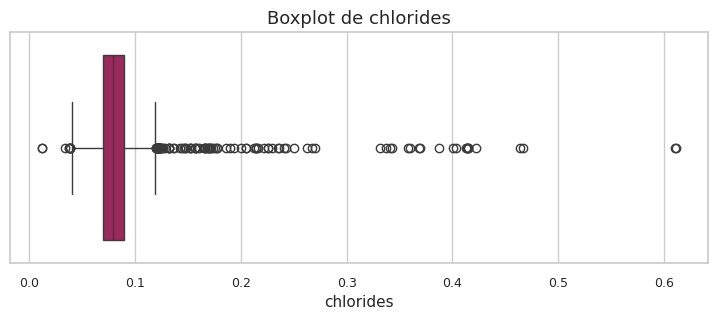

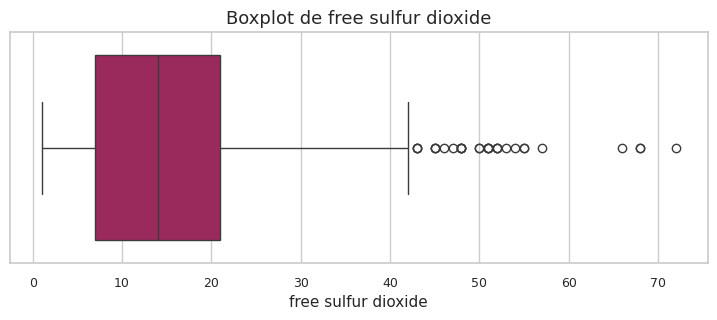

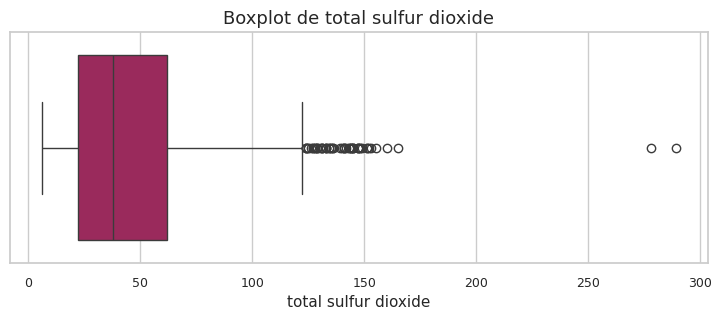

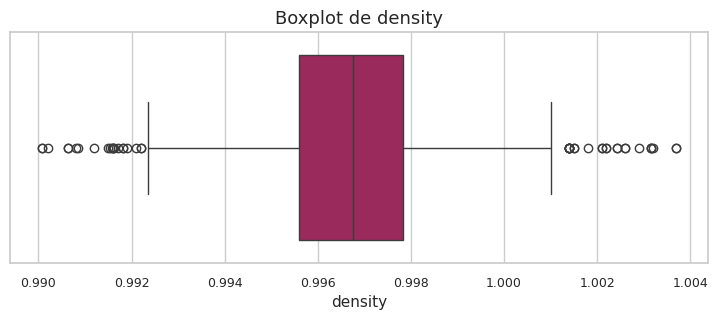

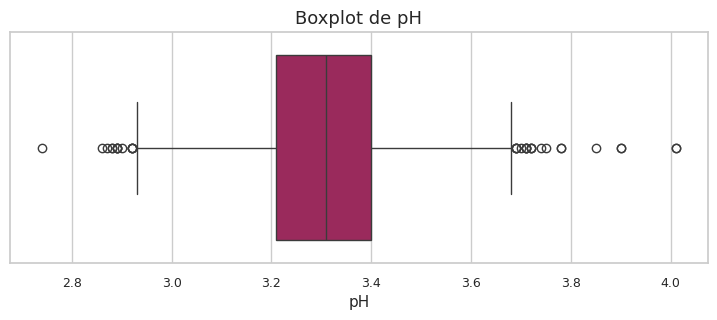

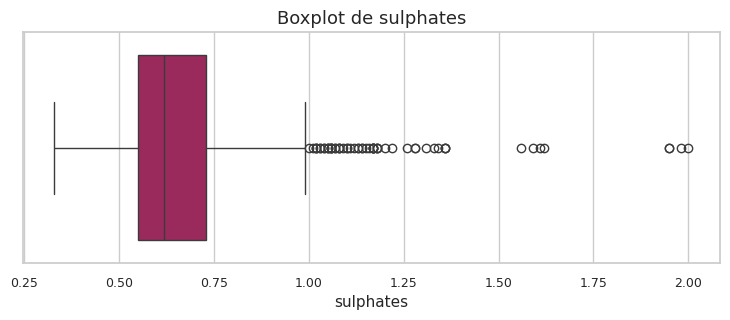

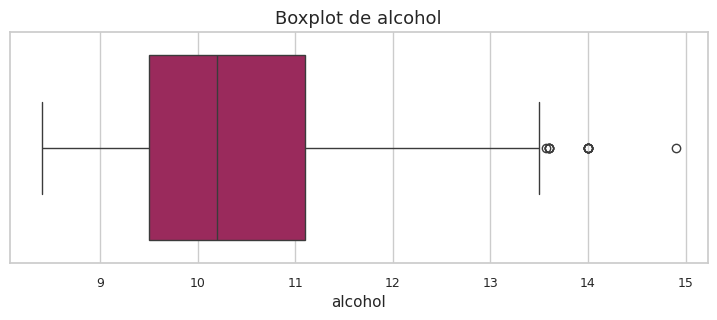

In [17]:
for variable in numeric_columns:
    plt.figure(figsize=(9, 3))
    
    sns.boxplot(
        data=df_wine_pd,
        x=variable,
        color=sns.color_palette("rocket")[2]
    )
    
    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    
    plt.show()

- **Análisis Multivariable**

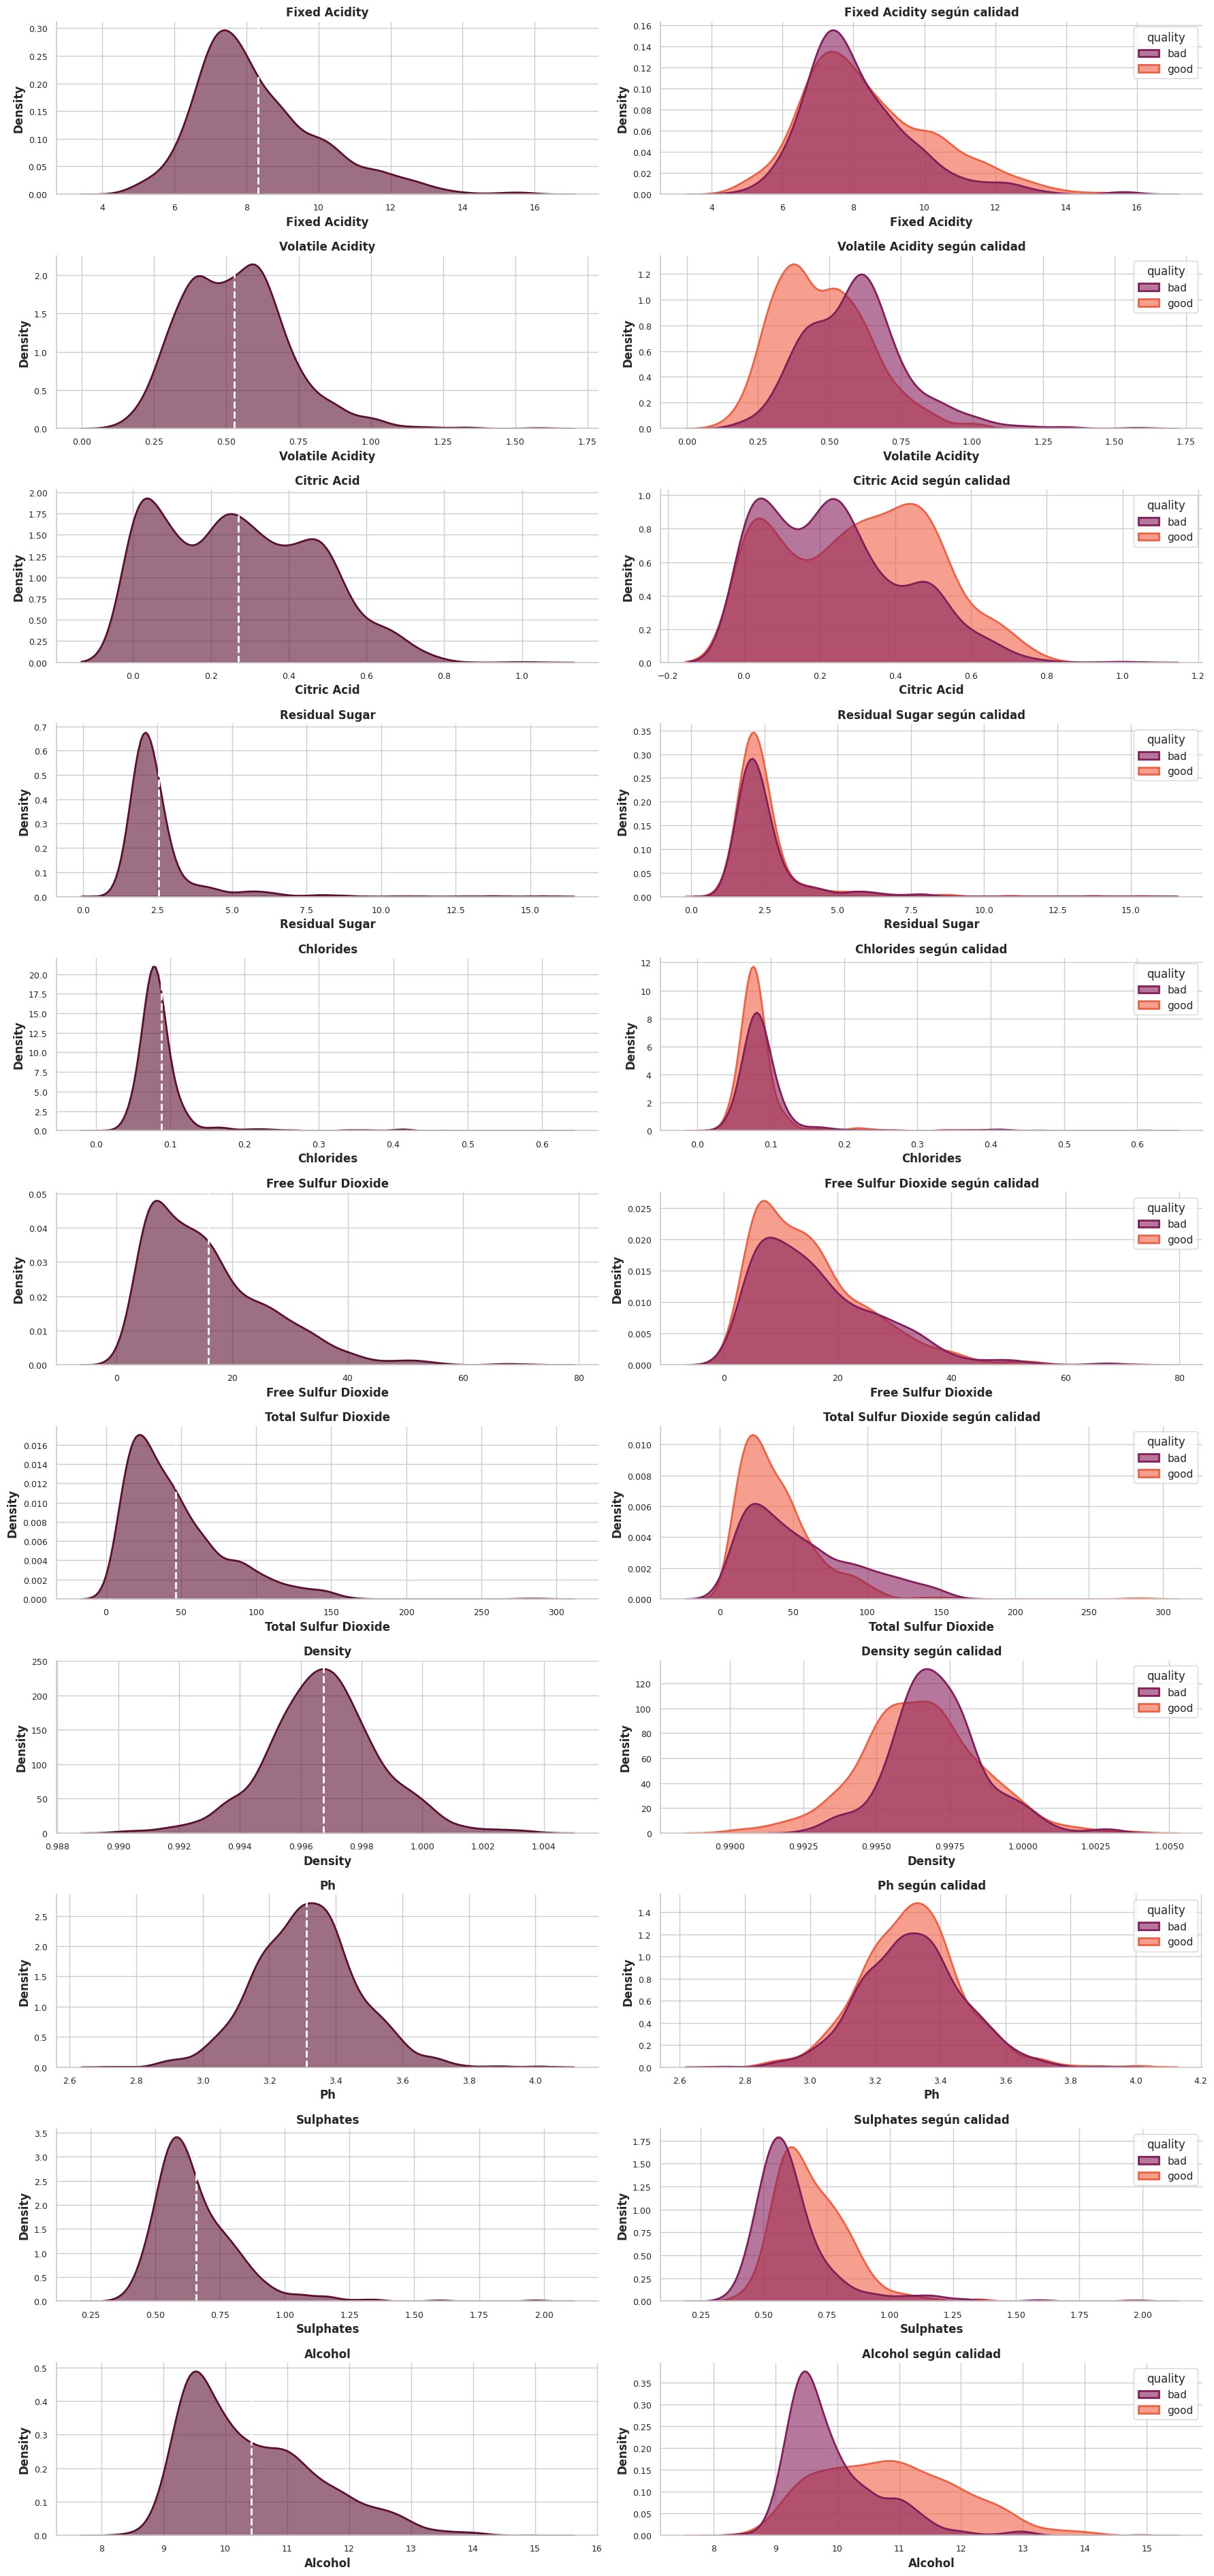

In [18]:
plot_index = 1

plt.figure(figsize=(18, 38))

for variable in numeric_columns:
    
    plt.subplot(11, 2, plot_index)
    
    sns.kdeplot(
        data=df_wine_pd,
        x=variable,
        fill=True,
        linewidth=2,
        color="#5c1031",
        alpha=0.6
    )
    
    plt.axvline(
        df_wine_pd[variable].mean(),
        color="white",
        linestyle="--",
        linewidth=2
    )
    
    plt.xlabel(variable.title(), fontsize=12, weight="bold")
    plt.ylabel("Density", fontsize=12, weight="bold")
    plt.title(variable.title(), fontsize=12, weight="bold")
    sns.despine()
    
    
    plt.subplot(11, 2, plot_index + 1)
    
    sns.kdeplot(
        data=df_wine_pd,
        x=variable,
        hue="quality",
        fill=True,
        linewidth=2,
        palette="rocket",
        alpha=0.6
    )
    
    plt.xlabel(variable.title(), fontsize=12, weight="bold")
    plt.ylabel("Density", fontsize=12, weight="bold")
    plt.title(f"{variable.title()} según calidad", fontsize=12, weight="bold")
    sns.despine()
    
    plot_index += 2

plt.tight_layout()
plt.show()

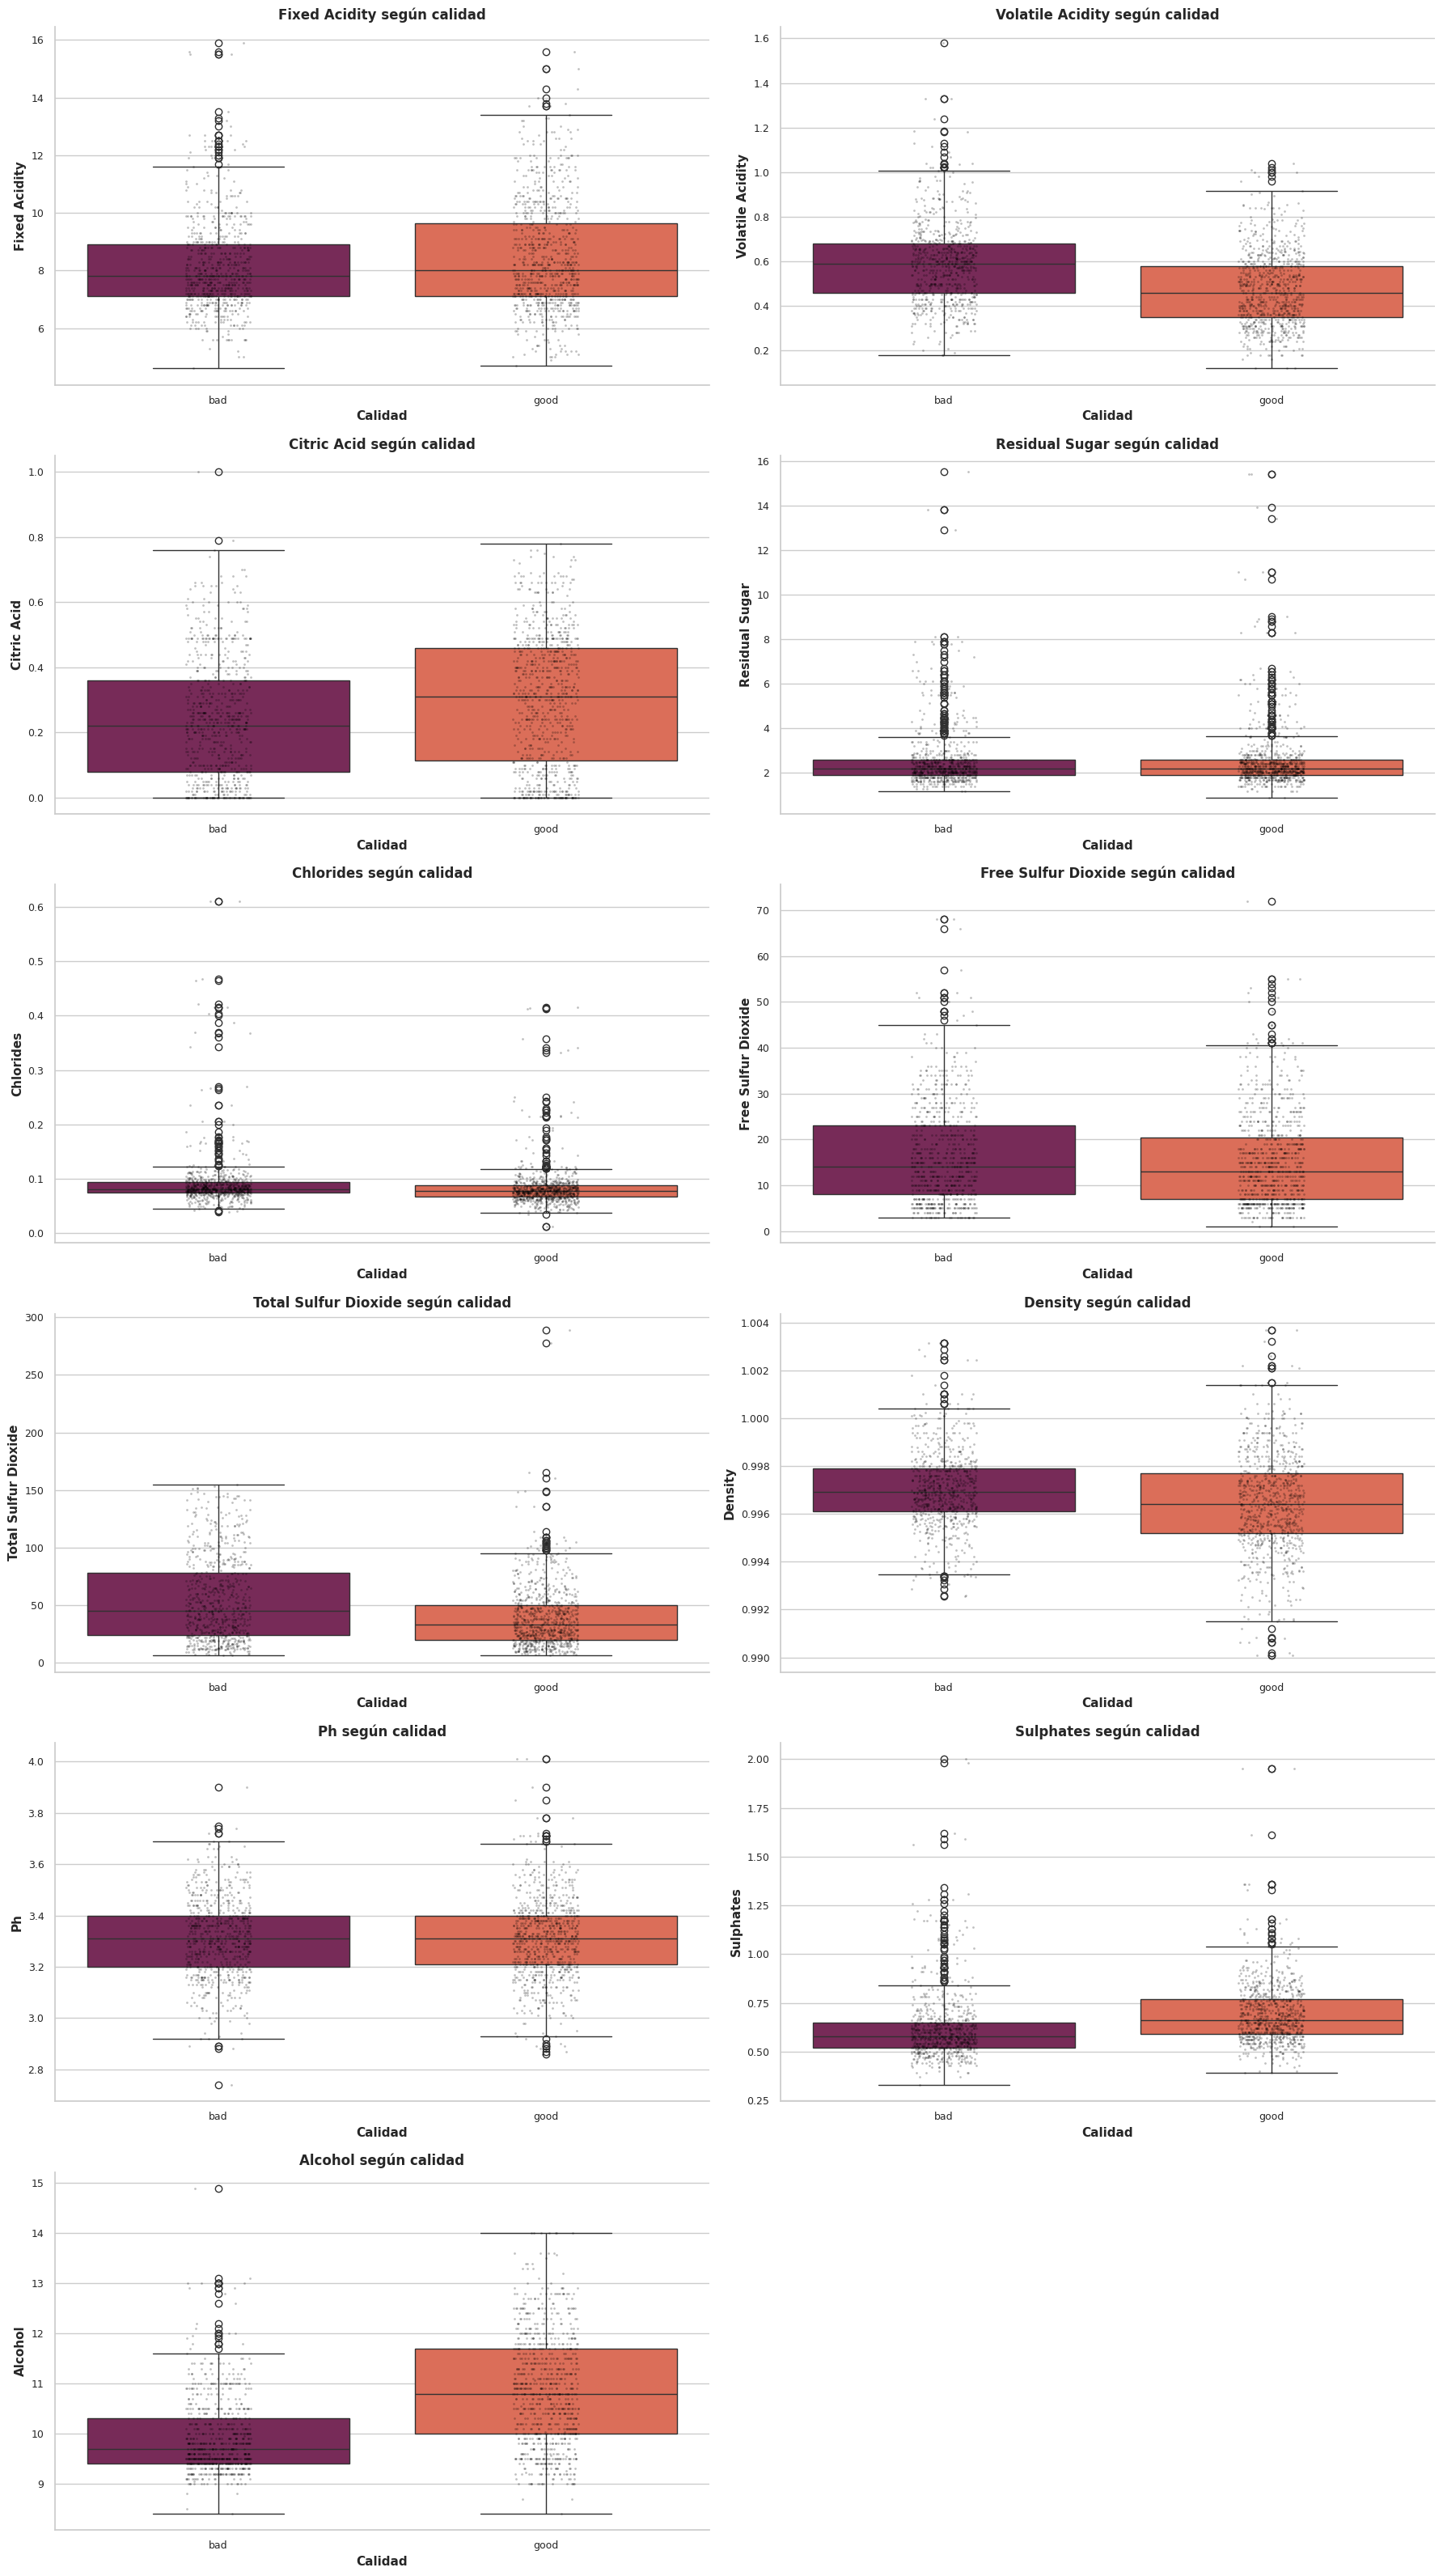

In [19]:
plt.figure(figsize=(18, 32))

plot_index = 1

for variable in numeric_columns:
    plt.subplot(6, 2, plot_index)

    sns.boxplot(
        data=df_wine_pd,
        x="quality",
        y=variable,
        hue="quality",
        palette="rocket",
        legend=False
    )

    sns.stripplot(
        data=df_wine_pd,
        x="quality",
        y=variable,
        color="black",
        alpha=0.25,
        size=2
    )

    plt.title(f"{variable.title()} según calidad", fontsize=12, weight="bold")
    plt.xlabel("Calidad", fontsize=11, weight="bold")
    plt.ylabel(variable.title(), fontsize=11, weight="bold")

    sns.despine()
    plot_index += 1

plt.tight_layout()
plt.show()

In [20]:
correlation_data = df_wine_pd[numeric_columns + ["label"]]

correlation_matrix = correlation_data.corr()

correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.095093
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.321441
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.159129
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,-0.002160
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.109494
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.061757
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.231963
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.159110
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.003264
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.218072


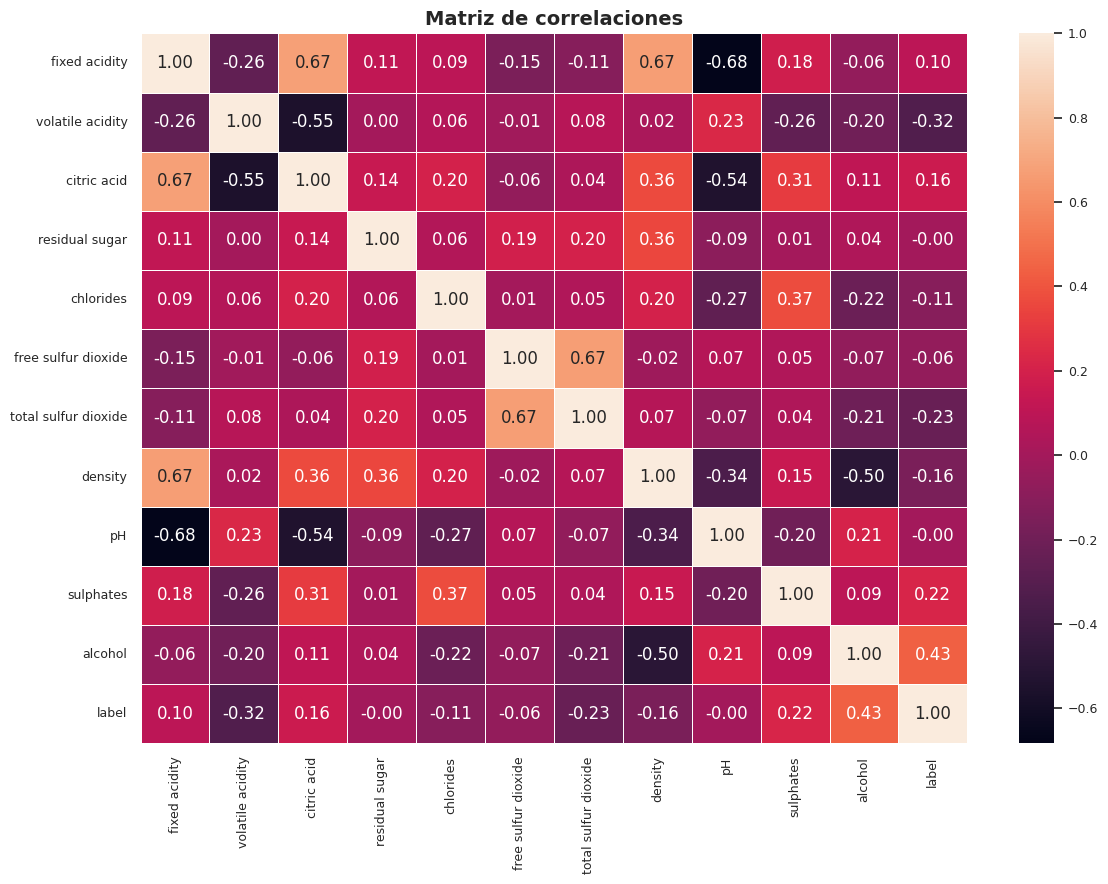

In [21]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    linewidths=0.5
)

plt.title("Matriz de correlaciones", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

In [22]:
target_correlation = (
    correlation_matrix["label"]
    .drop("label")
    .sort_values(ascending=False)
)

target_correlation

alcohol                 0.434751
sulphates               0.218072
citric acid             0.159129
fixed acidity           0.095093
residual sugar         -0.002160
pH                     -0.003264
free sulfur dioxide    -0.061757
chlorides              -0.109494
density                -0.159110
total sulfur dioxide   -0.231963
volatile acidity       -0.321441
Name: label, dtype: float64

/tmp/ipykernel_39/1417163984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


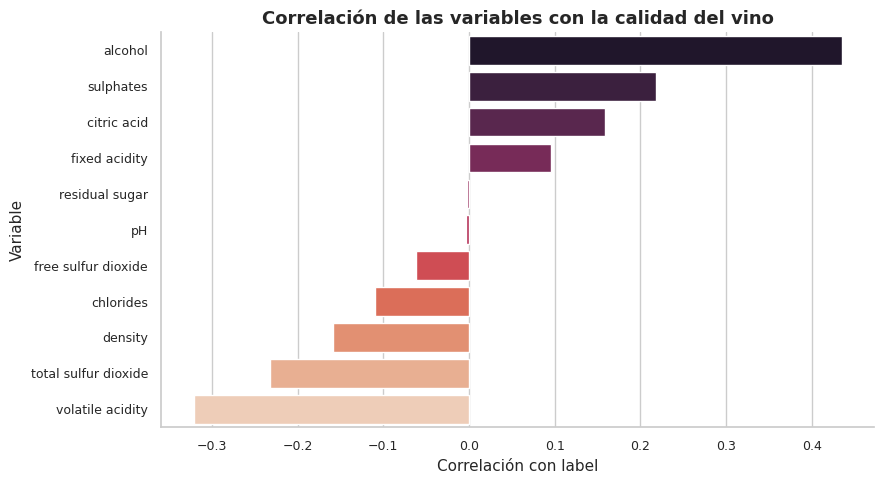

In [23]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index,
    palette="rocket"
)

plt.title("Correlación de las variables con la calidad del vino", fontsize=13, weight="bold")
plt.xlabel("Correlación con label")
plt.ylabel("Variable")

sns.despine()
plt.tight_layout()
plt.show()

**Normalización/Estandarización**

Las variables del conjunto de datos presentan escalas diferentes. Por ejemplo, variables como pH toman valores cercanos a 3 o 4, mientras que total_sulfur_dioxide puede alcanzar valores considerablemente mayores. Estas diferencias de magnitud pueden afectar el desempeño de algunos algoritmos de aprendizaje automático.

Por esta razón, se aplicará una técnica de estandarización utilizando la clase StandardScaler de Spark MLlib, con el objetivo de que las variables tengan una escala comparable antes del entrenamiento de los modelos.

In [24]:
feature_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

In [25]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df_wine_features = assembler.transform(df_wine)

In [26]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_wine_features)

df_wine_scaled = scaler_model.transform(df_wine_features)

**Escritura a base de datos**

In [27]:
tarea3 = df_wine.select(
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality",
    "label"
)

In [28]:
tarea3.show(5)
tarea3.printSchema()

print(f"Cantidad de registros a guardar: {tarea3.count()}")
print(f"Cantidad de columnas a guardar: {len(tarea3.columns)}")

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|label|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|    bad|    0|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|    bad|    0|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|    bad|    0|
|         11.2|            0.28|       0.56|           1.9|    0

In [29]:
jdbc_url = "jdbc:postgresql://postgres-t3:5432/tarea3"
jdbc_propiedades = {"user":"tarea3","password":"tarea3","driver":"org.postgresql.Driver"}

In [30]:
tarea3.write.jdbc(url=jdbc_url,table="tarea3",mode="overwrite",properties=jdbc_propiedades)

26/06/14 00:47:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


## Modelo 1 - Logistic Regression

In [31]:
# =========================================================
# Lectura desde PostgreSQL
# Esta tabla fue creada por Liz en la fase de preparacion de datos
# =========================================================
df_tarea3 = spark.read.jdbc(
    url=jdbc_url,
    table="tarea3",
    properties=jdbc_propiedades
)

print(f"Registros cargados desde PostgreSQL: {df_tarea3.count()}")
df_tarea3.printSchema()
df_tarea3.show(10)

Registros cargados desde PostgreSQL: 1599
root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: string (nullable = true)
 |-- label: integer (nullable = true)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|label|
+-------------+----------------+-----------+--------------+---------+---------------

In [32]:
# =========================================================
# Seleccion de variables basada en el analisis de correlacion con label
# Se excluyeron pH y residual sugar por tener correlacion practicamente nula
# con la variable objetivo (pH: -0.003, residual sugar: -0.002)
# Variables con mayor poder predictivo:
#   alcohol (+0.43), volatile acidity (-0.32),
#   total sulfur dioxide (-0.23), sulphates (+0.22)
# =========================================================
columnas_entrada = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    # "residual sugar" excluida: correlacion con label = -0.002
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    # "pH" excluida: correlacion con label = -0.003
    "sulphates",
    "alcohol"
]

# Se ensamblan las columnas en un vector de features
ensamblador = VectorAssembler(
    inputCols=columnas_entrada,
    outputCol="features"
)

# Se estandarizan los features para mitigar diferencias de escala entre columnas
# withMean=True y withStd=True aplica estandarizacion tipo Z-score
# importante para Logistic Regression porque es sensible a la escala
estandarizador = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

In [33]:
# =========================================================
# Se separan los datos en 80% entrenamiento y 20% validacion final
# La semilla se fija para garantizar reproducibilidad en cada ejecucion
# =========================================================
df_entrenamiento, df_validacion = df_tarea3.randomSplit([0.8, 0.2], seed=42)

print(f"Registros de entrenamiento: {df_entrenamiento.count()}")
print(f"Registros de validacion: {df_validacion.count()}")

Registros de entrenamiento: 1324
Registros de validacion: 275


## Entrenamiento - Modelo 1

In [34]:
# =========================================================
# Definicion del modelo Logistic Regression
# Se escoge Logistic Regression como modelo lineal de clasificacion binaria
# Es interpretable y sirve como linea base para comparar con modelos mas complejos
# =========================================================
regresion_logistica_wine = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=100
)

# Se define el pipeline con los pasos de preprocesamiento y el modelo
# Esto garantiza que el scaler se ajuste solo con datos de entrenamiento en cada fold
pipeline_wine = Pipeline(stages=[
    ensamblador,              # paso 1: ensamblar columnas en vector
    estandarizador,           # paso 2: estandarizar
    regresion_logistica_wine  # paso 3: entrenar el modelo
])

# =========================================================
# Grilla de hiperparametros para el CrossValidator
# regParam 0.01: poca regularizacion, modelo mas flexible
# regParam 0.1: mas regularizacion, penaliza coeficientes grandes
# elasticNetParam 0.0: Ridge L2, reduce coeficientes sin eliminarlos
# elasticNetParam 0.5: mezcla Ridge y Lasso, puede eliminar variables poco relevantes
# Total: 4 combinaciones x K=5 folds = 20 entrenamientos
# =========================================================
grilla_parametros = ParamGridBuilder() \
    .addGrid(regresion_logistica_wine.regParam, [0.01, 0.1]) \
    .addGrid(regresion_logistica_wine.elasticNetParam, [0.0, 0.5]) \
    .build()

# Evaluador basado en el area bajo la curva ROC
evaluador = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

In [35]:
# =========================================================
# CrossValidator con K=5 folds usando las funciones de Spark
# CrossValidator divide el conjunto de entrenamiento en K=5 partes (folds)
# Por cada combinacion de hiperparametros entrena 5 veces:
# cada vez usa 4 partes para entrenar y 1 para validar internamente
# Al final elige la combinacion con mejor AUC-ROC promedio entre los folds
# =========================================================
validacion_cruzada = CrossValidator(
    estimator=pipeline_wine,
    estimatorParamMaps=grilla_parametros,
    evaluator=evaluador,
    numFolds=5,
    seed=42
)

In [36]:
# Se entrena el modelo con K-Fold Cross Validation sobre el conjunto de entrenamiento
print("Entrenando modelo Logistic Regression con K-Fold Cross Validation...")
modelo_lr_wine = validacion_cruzada.fit(df_entrenamiento)
print("Entrenamiento finalizado.")

Entrenando modelo Logistic Regression con K-Fold Cross Validation...


26/06/14 00:47:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Entrenamiento finalizado.


In [37]:
# avgMetrics devuelve el AUC-ROC promedio de cada combinacion de hiperparametros
# durante el K-Fold. Con 4 combinaciones se obtienen 4 valores.
# El CrossValidator usa automaticamente la combinacion con el valor mas alto
# para construir el modelo final que se usara en la evaluacion
metricas_folds = modelo_lr_wine.avgMetrics
print("Metricas promedio por combinacion de hiperparametros (AUC-ROC):")
for i, metrica in enumerate(metricas_folds):
    print(f"  Combinacion {i+1}: {metrica:.4f}")

print(f"Mejor AUC-ROC en entrenamiento: {max(metricas_folds):.4f}")

Metricas promedio por combinacion de hiperparametros (AUC-ROC):
  Combinacion 1: 0.8120
  Combinacion 2: 0.8115
  Combinacion 3: 0.8086
  Combinacion 4: 0.8046
Mejor AUC-ROC en entrenamiento: 0.8120


## Evaluación - Modelo 1

In [38]:
# Se aplica el mejor modelo encontrado por CrossValidator sobre el conjunto de validacion
predicciones_validacion = modelo_lr_wine.transform(df_validacion)

# AUC-ROC: mide que tan bien separa el modelo las clases buena/mala
# 1.0 = perfecto, 0.5 = equivalente a adivinar al azar
auc_roc = evaluador.evaluate(predicciones_validacion)
print(f"AUC-ROC en validacion: {auc_roc:.4f}")

# Accuracy: porcentaje de predicciones correctas sobre el conjunto de validacion
evaluador_accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluador_accuracy.evaluate(predicciones_validacion)
print(f"Accuracy en validacion: {accuracy:.4f}")

# F1-Score: balance entre precision y recall
# util cuando las clases estan desbalanceadas (855 buenos vs 744 malos en este dataset)
evaluador_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)
f1 = evaluador_f1.evaluate(predicciones_validacion)
print(f'F1-Score en validacion: {f1:.4f}')

AUC-ROC en validacion: 0.8335
Accuracy en validacion: 0.7709
F1-Score en validacion: 0.7710


In [39]:
# Se seleccionan las mismas columnas de tarea3 mas la columna prediccion
# mas una columna adicional llamada prediccion con el resultado del modelo
# Se usa mode="overwrite" para sobreescribir si la tabla ya existe
columnas_tarea3 = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol", "quality", "label"
]

modelo1 = predicciones_validacion.select(
    *columnas_tarea3,
    col("prediction").alias("prediccion")
)

modelo1.show(5)
print(f"Registros a guardar en modelo1: {modelo1.count()}")

# Se escribe el resultado en la tabla modelo1 con modo overwrite
modelo1.write.jdbc(
    url=jdbc_url,
    table="modelo1",
    mode="overwrite",
    properties=jdbc_propiedades
)
print("Predicciones guardadas exitosamente en la tabla modelo1")

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|           alcohol|quality|label|prediccion|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|          4.9|            0.42|        0.0|           2.1|    0.048|               16.0|                42.0|0.99154|3.71|     0.74|              14.0|   good|    1|       1.0|
|          5.0|            0.74|        0.0|           1.2|    0.041|               16.0|                46.0|0.99258|4.01|     0.59|              12.5|   good|    1|       1.0|
|          5.0|            1.04|       0.24|           1.6|     0.05|               32.0|                96.0|

### Conclusión - Modelo 1 (Logistic Regression)

- **AUC-ROC: 0.8335** — buena capacidad de separación entre clases
- **Accuracy: 77.09%** y **F1-Score: 0.7710** — desempeño balanceado
- K-Fold estable: combinaciones entre 0.8046 y 0.8120, modelo consistente
- Logistic Regression establece una buena línea base para comparar con el Modelo 2

## Modelo 2 - Random Forest

In [40]:
# =========================================================
# Definicion del modelo Random Forest
# Modelo basado en ensamble de arboles de decision
# Captura relaciones no lineales entre las variables
# =========================================================

random_forest_wine = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="label",
    seed=42
)

In [41]:
pipeline_rf_wine = Pipeline(stages=[
    ensamblador,
    estandarizador,
    random_forest_wine
])

In [42]:
# =========================================================
# Grilla de hiperparametros para Random Forest
# =========================================================

grilla_rf = (
    ParamGridBuilder()
    .addGrid(random_forest_wine.numTrees, [20, 50, 100])
    .addGrid(random_forest_wine.maxDepth, [5, 10])
    .build()
)

In [43]:
# =========================================================
# Cross Validation K=5 para Random Forest
# =========================================================

validacion_cruzada_rf = CrossValidator(
    estimator=pipeline_rf_wine,
    estimatorParamMaps=grilla_rf,
    evaluator=evaluador,
    numFolds=5,
    seed=42
)

In [44]:
print("Entrenando modelo Random Forest con K-Fold Cross Validation...")

modelo_rf_wine = validacion_cruzada_rf.fit(df_entrenamiento)

print("Entrenamiento finalizado.")

Entrenando modelo Random Forest con K-Fold Cross Validation...


26/06/14 00:48:03 WARN DAGScheduler: Broadcasting large task binary with size 1182.7 KiB
26/06/14 00:48:03 WARN DAGScheduler: Broadcasting large task binary with size 1422.0 KiB
26/06/14 00:48:03 WARN DAGScheduler: Broadcasting large task binary with size 1035.7 KiB
26/06/14 00:48:05 WARN DAGScheduler: Broadcasting large task binary with size 1193.5 KiB
26/06/14 00:48:05 WARN DAGScheduler: Broadcasting large task binary with size 1693.2 KiB
26/06/14 00:48:05 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/06/14 00:48:05 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/06/14 00:48:05 WARN DAGScheduler: Broadcasting large task binary with size 1958.7 KiB
26/06/14 00:48:08 WARN DAGScheduler: Broadcasting large task binary with size 1207.8 KiB
26/06/14 00:48:08 WARN DAGScheduler: Broadcasting large task binary with size 1448.7 KiB
26/06/14 00:48:08 WARN DAGScheduler: Broadcasting large task binary with size 1054.0 KiB
26/06/14 00:48:09 WARN DAGS

Entrenamiento finalizado.


In [45]:
metricas_rf = modelo_rf_wine.avgMetrics

print("Metricas promedio por combinacion de hiperparametros (AUC-ROC):")

for i, metrica in enumerate(metricas_rf):
    print(f"  Combinacion {i+1}: {metrica:.4f}")

print(f"Mejor AUC-ROC en entrenamiento: {max(metricas_rf):.4f}")

Metricas promedio por combinacion de hiperparametros (AUC-ROC):
  Combinacion 1: 0.8311
  Combinacion 2: 0.8650
  Combinacion 3: 0.8333
  Combinacion 4: 0.8730
  Combinacion 5: 0.8360
  Combinacion 6: 0.8725
Mejor AUC-ROC en entrenamiento: 0.8730


In [46]:
mejor_rf = modelo_rf_wine.bestModel

modelo_rf_final = mejor_rf.stages[-1]

print("Numero de arboles:", modelo_rf_final.getNumTrees)
print("Profundidad maxima:", modelo_rf_final.getOrDefault("maxDepth"))

Numero de arboles: 50
Profundidad maxima: 10


## Evaluación - Modelo 2

In [47]:
predicciones_rf = modelo_rf_wine.transform(df_validacion)

# ROC-AUC
auc_roc_rf = evaluador.evaluate(predicciones_rf)

print(f"AUC-ROC en validacion: {auc_roc_rf:.4f}")

accuracy_rf = evaluador_accuracy.evaluate(predicciones_rf)

print(f"Accuracy en validacion: {accuracy_rf:.4f}")

f1_rf = evaluador_f1.evaluate(predicciones_rf)

print(f"F1-Score en validacion: {f1_rf:.4f}")

AUC-ROC en validacion: 0.8769
Accuracy en validacion: 0.8000


26/06/14 00:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1147.6 KiB
26/06/14 00:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1159.5 KiB
26/06/14 00:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1159.5 KiB


F1-Score en validacion: 0.8000


In [48]:
# Se seleccionan las mismas columnas de tarea3 mas la columna prediccion
# Se guardan las predicciones del modelo Random Forest en la tabla modelo2 para comparacion con modelo1

modelo2 = predicciones_rf.select(
    *columnas_tarea3,
    col("prediction").alias("prediccion")
)

modelo2.show(5)

print(f"Registros a guardar en modelo2: {modelo2.count()}")

modelo2.write.jdbc(
    url=jdbc_url,
    table="modelo2",
    mode="overwrite",
    properties=jdbc_propiedades
)

print("Predicciones guardadas exitosamente en la tabla modelo2")

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|           alcohol|quality|label|prediccion|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|          4.9|            0.42|        0.0|           2.1|    0.048|               16.0|                42.0|0.99154|3.71|     0.74|              14.0|   good|    1|       1.0|
|          5.0|            0.74|        0.0|           1.2|    0.041|               16.0|                46.0|0.99258|4.01|     0.59|              12.5|   good|    1|       1.0|
|          5.0|            1.04|       0.24|           1.6|     0.05|               32.0|                96.0|

26/06/14 00:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1145.3 KiB
26/06/14 00:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1150.1 KiB


In [49]:
verificacion_modelo2 = spark.read.jdbc(
    url=jdbc_url,
    table="modelo2",
    properties=jdbc_propiedades
)

verificacion_modelo2.show(5)

print(
    f"Registros almacenados en modelo2: "
    f"{verificacion_modelo2.count()}"
)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|           alcohol|quality|label|prediccion|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+------------------+-------+-----+----------+
|          4.9|            0.42|        0.0|           2.1|    0.048|               16.0|                42.0|0.99154|3.71|     0.74|              14.0|   good|    1|       1.0|
|          5.0|            0.74|        0.0|           1.2|    0.041|               16.0|                46.0|0.99258|4.01|     0.59|              12.5|   good|    1|       1.0|
|          5.0|            1.04|       0.24|           1.6|     0.05|               32.0|                96.0|

### Conclusión - Modelo 2 (Random Forest)

- **AUC-ROC: 0.8769** — excelente capacidad de separación entre clases.
- **Accuracy: 80.00%** y **F1-Score: 0.8** — desempeño balanceado y sólido en el conjunto de validación.
- K-Fold estable: combinaciones entre 0.8311 y 0.8730, indica un modelo con buena estabilidad frente a diferentes particiones de los datos.
- Debido a que Random Forest es un modelo que permite capturar relaciones no lineales e interacciones complejas, este logró un mejor desempeño que el obtenido por Logistic Regression.

## Análisis comparativo de resultados

             Modelo  AUC-ROC  Accuracy  F1-Score
      Random Forest   0.8769    0.8000     0.800
Logistic Regression   0.8335    0.7709     0.771


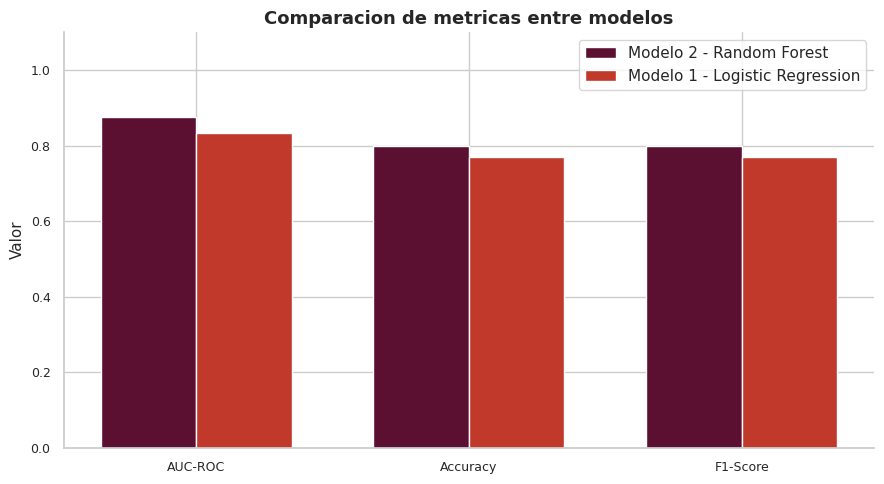

In [50]:
# =========================================================
# Comparacion entre Modelo 1 (Logistic Regression) y Modelo 2 (Random Forest)
# =========================================================
resultados_comparacion = {
    "Modelo": ["Random Forest", "Logistic Regression"],
    "AUC-ROC": [round(auc_roc_rf, 4), round(auc_roc, 4)],
    "Accuracy": [round(accuracy_rf, 4), round(accuracy, 4)],
    "F1-Score": [round(f1_rf, 4), round(f1, 4)]
}

df_comparacion = pd.DataFrame(resultados_comparacion)
print(df_comparacion.to_string(index=False))

# Grafico comparativo
metricas_nombres = ["AUC-ROC", "Accuracy", "F1-Score"]
valores_rf = [round(auc_roc_rf, 4), round(accuracy_rf, 4), round(f1_rf, 4)]
valores_lr = [round(auc_roc, 4), round(accuracy, 4), round(f1, 4)]

x = range(len(metricas_nombres))
ancho_barra = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - ancho_barra/2 for i in x], valores_rf, ancho_barra,
       label="Modelo 2 - Random Forest", color="#5c1031")
ax.bar([i + ancho_barra/2 for i in x], valores_lr, ancho_barra,
       label="Modelo 1 - Logistic Regression", color="#c0392b")

ax.set_ylabel("Valor")
ax.set_title("Comparacion de metricas entre modelos", fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(metricas_nombres)
ax.legend()
ax.set_ylim(0, 1.1)
sns.despine()
plt.tight_layout()
plt.show()

## Conclusiones

Ambos modelos tienen un desempeño satisfactorio para la clasificación de la calidad del vino.

El modelo Random Forest alcanzó un AUC-ROC de 0.8769, en comparación con Logistic Regression (0.8335), esto indica una mejor capacidad para distinguir entre vinos de calidad alta y baja. De la misma manera, obtuvo valores de Accuracy y F1-Score mejores que Logistic Regression.

Dado lo anterior el modelo Random Forest obtuvo un mejor desempeño y se considera la mejor alternativa para este conjunto de datos, debido a su capacidad de modelar relaciones no lineales.
